In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import json
from sklearn.decomposition import PCA
from PIL import Image
import yaml

import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import v2
import torchvision.transforms as transforms
from torchvision.models import vit_l_16, ViT_L_16_Weights
from torchvision.io import decode_image

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.base_cam import BaseCAM

from scripts.model import Custom_ResNet50, Custom_DenseNet121, ModelWrapper
from scripts.preprocessing import get_hilbert_index, hilbert_ravel, pipeline
import scripts.gradcam

# View Grad-CAM Mask Similarities Between Conditions

Although

In [2]:
# Load variables

##### Import common.yaml
with open("config/common.yaml", "r") as common_params:
    common = yaml.safe_load(common_params)
    # unpack params
    conditions = common["conditions"]
    class_cols = common["class_cols"]
    n_classes = common["n_classes"]

### Load wrapper_kwargs
with open("config/wrapper_kwargs.yaml", "r") as params:
    wrapper_kwargs = yaml.safe_load(params)

In [3]:
model_types = ["ResNet50", "ResNet50", "ResNet50", "ResNet50", 
               "DenseNet121", "DenseNet121", "DenseNet121", "DenseNet121"]
dims = [224, 224, 224, 224,
        384, 384, 384, 384]
enhanceds = [False, True, False, True,
             False, True, False, True]

model_types = ["ResNet50", "ResNet50", "DenseNet121", "DenseNet121"]
dims = [224, 224, 224, 224]
enhanceds = [False, True, False, True]


In [4]:
### Number of X-rays to loop through for each model
pca_sample_size = 100

### Number of PCA components
n_pca_components = 5

### Loop through the models

In [5]:
output_dict = {}
for i,(model_type, dim, enhanced) in enumerate(zip(model_types, dims, enhanceds)):
    t0 = time.time()
    label = str(model_type) + "_" + str(dim) + "_" + str("ENHANCED" if enhanced==True else "RAW")
    print(f"Starting analysis on {label}")
    
    ##### Assemble the variables
    wrapper_kwargs_i = wrapper_kwargs[f"wrapper_kwargs{i}"]
    wrapper_kwargs_i["pca_sample_size"] = pca_sample_size
    wrapper_kwargs_i["n_pca_components"] = n_pca_components
    
    #####
    output_dict[label] = scripts.gradcam.gradcam_pca_analysis(**wrapper_kwargs_i)
    print(f"\tComplete ---> Time elapsed: {round(time.time() - t0, 2)} s")



Starting analysis on ResNet50_224_RAW
	Complete ---> Time elapsed: 29.75 s
Starting analysis on ResNet50_224_ENHANCED
	Complete ---> Time elapsed: 29.27 s
Starting analysis on DenseNet121_224_RAW
	Complete ---> Time elapsed: 77.77 s
Starting analysis on DenseNet121_224_ENHANCED
	Complete ---> Time elapsed: 78.23 s


In [14]:
# Save analysis
results_filename = "results/gradcam/PCA_analysis_dicts.json"

with open(results_filename, "w") as fh:
    fh.write(str(output_dict))

In [16]:
# Open analysis for viewing
with open(results_filename, "r") as fh:
    results_dict = eval(fh.read().replace("array", "np.array"))

In [19]:
print("PCA_analysis_dicts Structure\n")
for key,val in results_dict.items():
    print(key)
    for key2,val2 in val.items():
        print("     ", key2)

PCA_analysis_dicts Structure

ResNet50_224_RAW
      avg_dot
      avg_L2
      avg_corr
      avg_explained_variance
      avg_explained_variance_ratios
ResNet50_224_ENHANCED
      avg_dot
      avg_L2
      avg_corr
      avg_explained_variance
      avg_explained_variance_ratios
DenseNet121_224_RAW
      avg_dot
      avg_L2
      avg_corr
      avg_explained_variance
      avg_explained_variance_ratios
DenseNet121_224_ENHANCED
      avg_dot
      avg_L2
      avg_corr
      avg_explained_variance
      avg_explained_variance_ratios


In [21]:
### Plot average explained variance
avg_explained_variance = {}
for mod1,values1 in results_dict.items():
    avg_explained_variance[mod1] = results_dict[mod1]["avg_explained_variance"]

avg_explained_variance

{'ResNet50_224_RAW': 1.0,
 'ResNet50_224_ENHANCED': 1.0000000000000002,
 'DenseNet121_224_RAW': 1.0,
 'DenseNet121_224_ENHANCED': 1.0}

In [49]:
pca_df = results_dict["DenseNet121_224_ENHANCED"]

Performing PCA on gradcams with 5 components

Average amount of variance explained (using hilbert curve): 1.0
Average amount of variance explained (using ravel()): 1.0

PCA is performed on individual images to determine similarities between gradcams

Average fraction of variance explained as the number of components increases:
0: 0
1: 0.666407701
2: 0.930712639
3: 0.9779034602
4: 1.0
5: 1.0


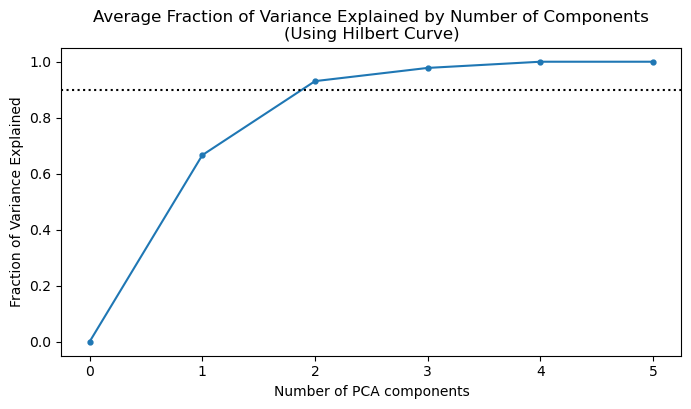

In [50]:
### Get average similarity measures
# Similarity is measured between gradcams of different conditions on the SAME x-ray
# The similarity is then averaged across the set

print(f"Performing PCA on gradcams with {n_pca_components} components\n")
print(f"Average amount of variance explained (using hilbert curve): {pca_df["avg_explained_variance"]}")
print(f"Average amount of variance explained (using ravel()): {pca_df["avg_explained_variance"]}")
print()
print("PCA is performed on individual images to determine similarities between gradcams")

dot_df1 = pd.DataFrame(pca_df["avg_dot"], index=conditions, columns=conditions)
L2_df1 = pd.DataFrame(pca_df["avg_L2"], index=conditions, columns=conditions)
#
mask1 = np.triu(pca_df["avg_dot"], k=0)

print()

### Plot the variance explained
fig,ax = plt.subplots(1,1, figsize=(8,4))
plot_evr =  [0] + [i for i in pca_df["avg_explained_variance_ratios"].cumsum()]

ax.plot(plot_evr, marker="o", markersize=3.5)
ax.axhline(0.9, linestyle=":", color="k")
ax.set(title="Average Fraction of Variance Explained by Number of Components\n(Using Hilbert Curve)",
       ylabel="Fraction of Variance Explained",
       xlabel="Number of PCA components",
       xticks=range(0, n_pca_components + 1, 1))

print(F"Average fraction of variance explained as the number of components increases:")
for i,evr in enumerate(plot_evr):
    print(f"{i}: {evr}")

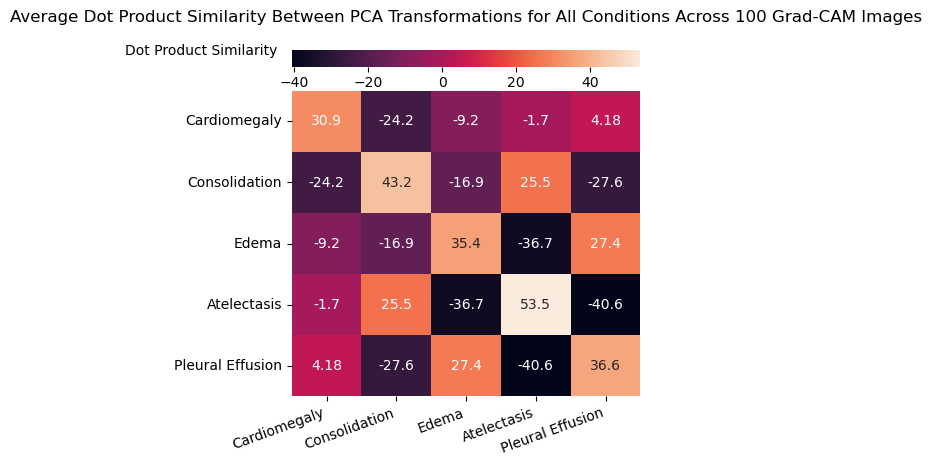

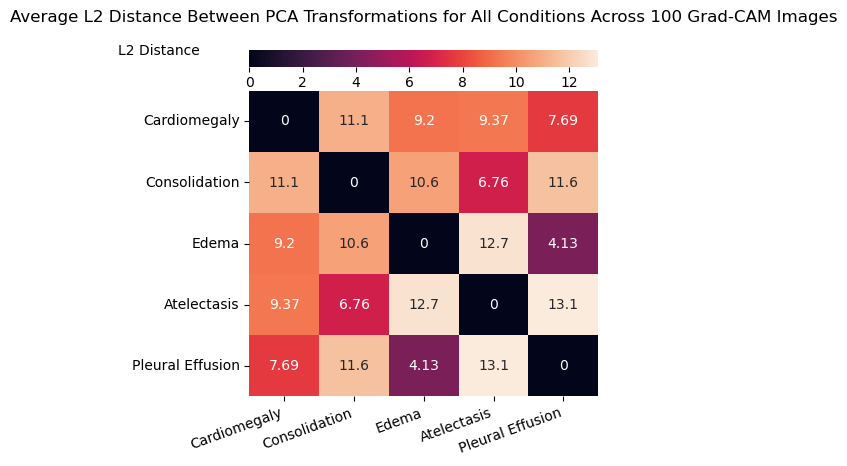

In [51]:
### Visualize dfs in a heatmap
plot_vars = [(dot_df1, "Dot Product Similarity"), 
             (L2_df1, "L2 Distance")]

###
for (plot_df, plot_type) in plot_vars:
    grid_kws = {"height_ratios": (.05, .9), "hspace": .15}
    fig,ax = plt.subplots(2, gridspec_kw=grid_kws, figsize=(4.5,4.5))

    if plot_type=="L2 Distance":
        # sns.heatmap(plot_df, ax=ax[1], annot=True, mask=mask1, cbar_ax=ax[0], cbar_kws={"orientation":"horizontal"}, fmt=".3g", cmap=sns.cm.rocket, vmin=0)
        sns.heatmap(plot_df, ax=ax[1], annot=True, cbar_ax=ax[0], cbar_kws={"orientation":"horizontal"}, fmt=".3g", cmap=sns.cm.rocket, vmin=0)
    else:
        sns.heatmap(plot_df, ax=ax[1], annot=True, cbar_ax=ax[0], cbar_kws={"orientation":"horizontal"}, fmt=".3g")
        # sns.heatmap(plot_df, ax=ax[1], annot=True, mask=mask1, cbar_ax=ax[0], cbar_kws={"orientation":"horizontal"}, fmt=".3g")
    plt.xticks(rotation=20, ha="right")
    
    ax[0].set_title(f"Average {plot_type} Between PCA Transformations for All Conditions Across {pca_sample_size} Grad-CAM Images", pad=20)
    ax[0].set_ylabel(plot_type, rotation=0, labelpad=65)
    
    plt.show()
